# MLS "Moneyball" Salary Cap Optimizer

Welcome to the Major League Soccer (MLS) "Moneyball" Salary Cap Optimizer. This notebook combines data from two powerful soccer analytics sources to find undervalued talent and construct the optimal starting XI under a strict salary cap:

1. **American Soccer Analysis (ASA) API:** We fetch advanced performance data, specifically **Goals Added (g+)**. This metric quantifies a player's total on-ball contribution (passing, dribbling, defending, shot-stopping, etc.) by measuring how much their actions increase their team's probability of scoring or decrease the opponent's probability of scoring.
2. **MLS Players Association (MLSPA) Salaries:** We fetch official player salary data to determine the cost of each player.

We will formulate this as an **Integer Linear Programming (ILP)** problem (a variation of the classic Knapsack Problem) and solve it using the `PuLP` library to build the highest-performing squad within a user-defined budget and formation.

## 1. Setup & Initialization

First, we import the required libraries and initialize the `AmericanSoccerAnalysis` client.

In [1]:
import pandas as pd
from itscalledsoccer.client import AmericanSoccerAnalysis
import pulp
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

# Initialize the ASA API client
asa = AmericanSoccerAnalysis()
print("ASA client successfully initialized!")

ASA client successfully initialized!


## 2. Data Fetching

We pull data for the target season (default: **2024**). We fetch three tables:
- **Players Directory:** Master player details (positions, nationalities, height, weight).
- **Salaries:** Official player base salaries and guaranteed compensation.
- **Outfield Goals Added (g+):** Detailed on-field contributions for defenders, midfielders, and forwards.
- **Goalkeeper Goals Added (g+):** Detailed on-field contributions for goalkeepers.

In [ ]:
season = 2025

print(f"Fetching 2024 MLS data...")
players_df = asa.get_players(leagues="mls")
salaries_df = asa.get_player_salaries(leagues="mls", season_name=season)
outfield_gplus = asa.get_player_goals_added(leagues="mls", season_name=season)
gk_gplus = asa.get_goalkeeper_goals_added(leagues="mls", season_name=season)

print(f"Loaded {len(players_df)} total players registry records.")
print(f"Loaded {len(salaries_df)} salary records for {season}.")
print(f"Loaded {len(outfield_gplus)} outfield player g+ records for {season}.")
print(f"Loaded {len(gk_gplus)} goalkeeper g+ records for {season}.")

Fetching 2024 MLS data...
Loaded 3506 total players registry records.
Loaded 1786 salary records for 2024.
Loaded 736 outfield player g+ records for 2024.
Loaded 66 goalkeeper g+ records for 2024.


## 3. Data Wrangling & Cleaning

Now we prepare the data for analysis:
1. **Deduplicate Salaries:** The MLSPA publishes salaries twice a year (Spring and Fall). We sort by the release date and keep the latest salary record for each player.
2. **Merge Goalkeepers:** Outfield and goalkeeper g+ datasets are structured slightly differently. We label the goalkeepers with position `'GK'`, concat them with the outfield players, and calculate the total sum of `goals_added_raw` for each player.
3. **Join Tables:** Merge player metadata, salaries, and performance data into a single master dataframe.
4. **Filter Playtime:** Filter out players with less than 450 minutes played (equivalent to 5 full games) to eliminate statistical noise from low sample sizes.

In [3]:
# 1. Clean salaries: keep latest release for each player
clean_salaries = salaries_df.sort_values("mlspa_release").groupby("player_id").last().reset_index()

# 2. Deduplicate player registry metadata
clean_players = players_df.drop_duplicates(subset=["player_id"])

# 3. Label and combine goals added datasets
gk_gplus['general_position'] = 'GK'
all_gplus = pd.concat([outfield_gplus, gk_gplus], ignore_index=True)

# 4. Calculate total Goals Added (g+) sum across all actions
all_gplus['total_gplus'] = all_gplus['data'].apply(lambda x: sum(item['goals_added_raw'] for item in x))

# 5. Merge datasets
merged = all_gplus.merge(clean_players, on="player_id", how="left")
merged = merged.merge(clean_salaries[["player_id", "base_salary", "guaranteed_compensation"]], on="player_id", how="inner")

# 6. Final cleaning and filtering
df_clean = merged.dropna(subset=["primary_broad_position", "guaranteed_compensation", "total_gplus"])
df_clean = df_clean[df_clean['minutes_played'] >= 450].copy()

print(f"Data wrangled. {len(df_clean)} players meet the selection criteria.")
print(df_clean['primary_broad_position'].value_counts())

Data wrangled. 604 players meet the selection criteria.
primary_broad_position
MF    235
DF    232
FW     95
GK     42
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

Let's visualize the relationship between player guaranteed compensation (salary) and their Goals Added (g+) contribution. 

Under a traditional squad-building approach, you might assume higher salary translates directly to higher impact. Let's see if that assumption holds true in MLS.

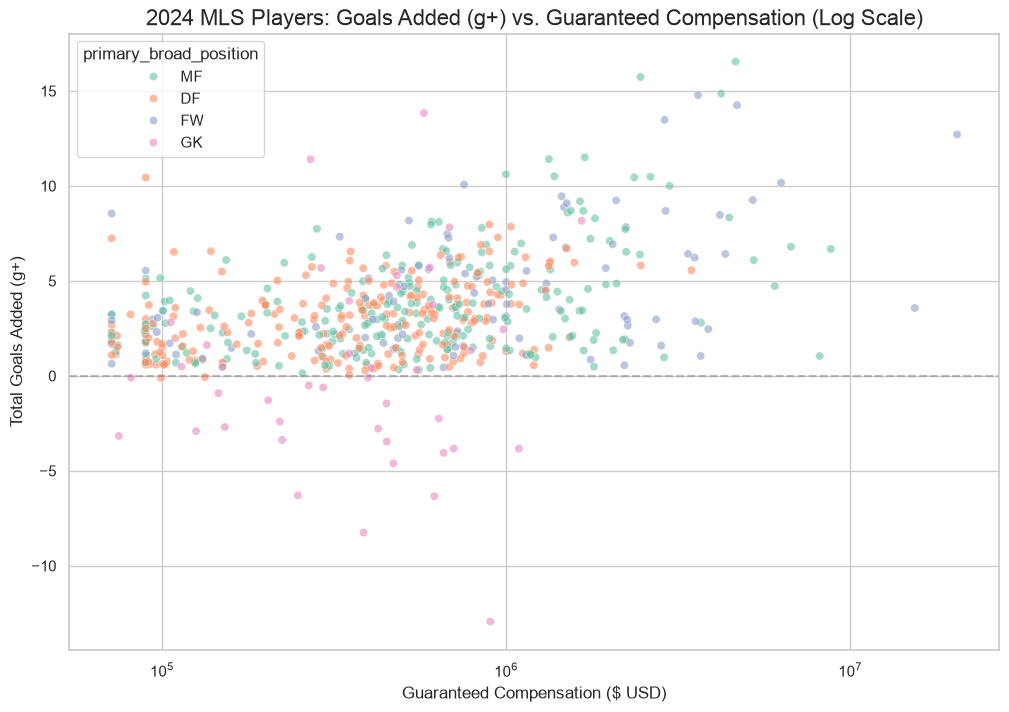

In [4]:
# Plot Goals Added vs. Salary
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_clean,
    x="guaranteed_compensation",
    y="total_gplus",
    hue="primary_broad_position",
    alpha=0.6,
    palette="Set2"
)
plt.xscale('log')
plt.title(f"{season} MLS Players: Goals Added (g+) vs. Guaranteed Compensation (Log Scale)", fontsize=16)
plt.xlabel("Guaranteed Compensation ($ USD)", fontsize=12)
plt.ylabel("Total Goals Added (g+)", fontsize=12)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.show()

Notice the massive clustering in the bottom left (low salary, low/average contribution) but also how some players on low salaries achieve incredibly high g+ scores (e.g. g+ > 6.0 while earning under $150k). Conversely, some players earning millions have negative or near-zero g+ metrics. These low-cost, high-performing players are our **"Moneyball bargains"**.

## 5. Roster Optimization Engine

We model this problem as a Binary Integer Linear Program:
- Let $x_i \in \{0, 1\}$ be a decision variable indicating whether player $i$ is selected in the squad ($1$) or not ($0$).
- **Objective:** Maximize the sum of player contributions:
  $$\max \sum_i (\text{g+}_i \times x_i)$$
- **Constraints:**
  - **Budget:** $\sum_i (\text{Salary}_i \times x_i) \leq \text{Budget}$
  - **Squad Size:** $\sum_i x_i = 11$
  - **Positions:** Force the squad to align with a specified formation (e.g., 4-3-3: 1 GK, 4 DF, 3 MF, 3 FW)

In [5]:
def optimize_starting_xi(data, budget, formation):
    """
    Optimizes the starting XI using PuLP solver.
    
    Parameters:
        data (pd.DataFrame): Wrangled player dataframe
        budget (float): Roster budget cap
        formation (dict): Roster requirements per position, e.g., {'GK': 1, 'DF': 4, 'MF': 3, 'FW': 3}
    """
    # Initialize maximization problem
    prob = pulp.LpProblem("MLS_Moneyball_Starting_XI", pulp.LpMaximize)
    
    # Create binary decision variables
    indices = data.index.tolist()
    x = pulp.LpVariable.dicts("player", indices, cat="Binary")
    
    # Objective: Maximize Goals Added
    prob += pulp.lpSum(data.loc[i, "total_gplus"] * x[i] for i in indices)
    
    # Constraint 1: Salary budget cap
    prob += pulp.lpSum(data.loc[i, "guaranteed_compensation"] * x[i] for i in indices) <= budget
    
    # Constraint 2: Total player count must be 11
    prob += pulp.lpSum(x[i] for i in indices) == 11
    
    # Constraint 3: Specific formation position requirements
    for pos, count in formation.items():
        prob += pulp.lpSum(x[i] for i in indices if data.loc[i, "primary_broad_position"] == pos) == count
        
    # Solve the problem
    status = prob.solve(pulp.PULP_CBC_CMD(msg=False))
    
    if status == pulp.LpStatusOptimal:
        selected_indices = [i for i in indices if x[i].varValue == 1]
        squad = data.loc[selected_indices].copy()
        return squad, True
    else:
        return None, False

## 6. Run the Optimizer

Let's select a starting 11 for a standard **4-3-3 formation** with a total salary budget of **$5,000,000** (under the typical MLS salary cap, leaving room for bench depth).

In [6]:
budget = 5000000
formation = {
    "GK": 1,
    "DF": 4,
    "MF": 3,
    "FW": 3
}

optimized_squad, success = optimize_starting_xi(df_clean, budget, formation)

if success:
    print(f"Success! Optimal starting XI found under budget of ${budget:,}.")
    print(f"Total Squad Cost: ${optimized_squad['guaranteed_compensation'].sum():,}")
    print(f"Total Squad Goals Added (g+): {optimized_squad['total_gplus'].sum():.4f}\n")
    
    # Display clean table
    cols = ["player_name", "primary_broad_position", "minutes_played", "guaranteed_compensation", "total_gplus"]
    display_df = optimized_squad[cols].sort_values(by="primary_broad_position")
    print(display_df.to_string(index=False))
else:
    print("No feasible squad could be generated under this budget and formation. Try increasing the budget.")

Success! Optimal starting XI found under budget of $5,000,000.
Total Squad Cost: $4,944,802
Total Squad Goals Added (g+): 101.1944

       player_name primary_broad_position  minutes_played  guaranteed_compensation  total_gplus
    Andrew Privett                     DF            3353                    71401       7.2436
    Joseph Rosales                     DF            2980                   138690       6.5639
     Luca Orellano                     DF            3173                    89716      10.4416
     Jackson Ragen                     DF            3690                   108261       6.5283
       Brian White                     FW            3059                   754500      10.0702
  Patrick Agyemang                     FW            2266                    71401       8.5459
     William Agada                     FW            1947                   521875       8.1778
 Kristijan Kahlina                     GK            3780                   576875      13.8417
Sant

## 7. Visualize the Optimized Squad

Let's plot the selected players on top of our original Goals Added vs. Salary scatter plot to see where they fall in the overall league landscape.

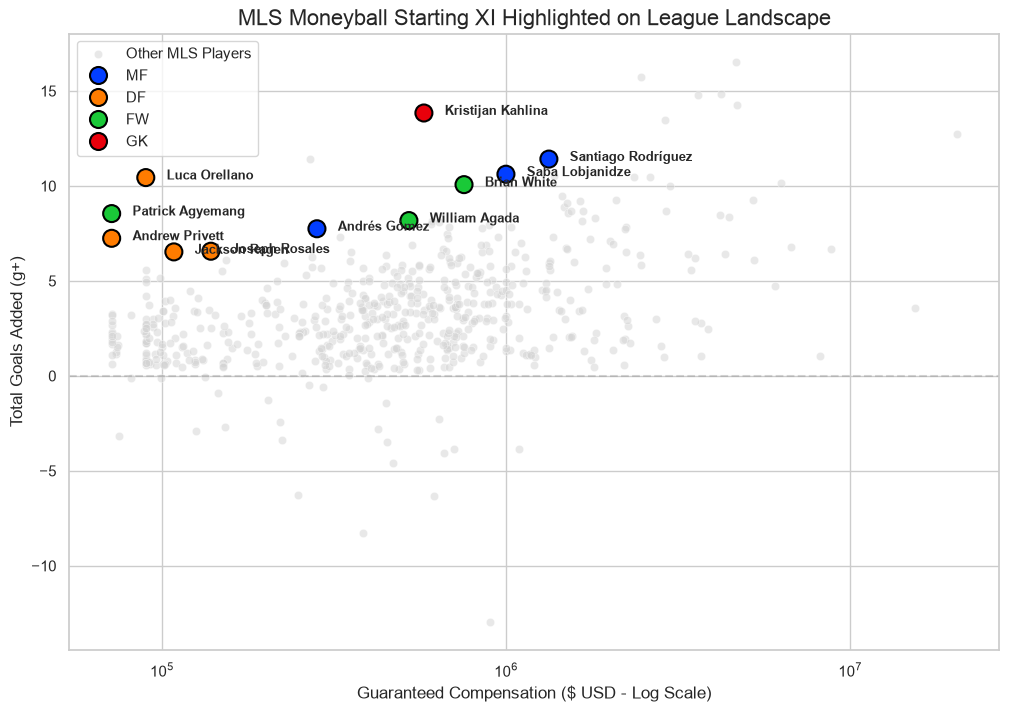

In [7]:
if success:
    plt.figure(figsize=(12, 8))
    
    # Plot all players
    sns.scatterplot(
        data=df_clean,
        x="guaranteed_compensation",
        y="total_gplus",
        color="lightgray",
        alpha=0.5,
        label="Other MLS Players"
    )
    
    # Highlight selected starting XI
    sns.scatterplot(
        data=optimized_squad,
        x="guaranteed_compensation",
        y="total_gplus",
        hue="primary_broad_position",
        palette="bright",
        s=150,
        edgecolor="black",
        linewidth=1.5
    )
    
    # Label player names
    for _, row in optimized_squad.iterrows():
        plt.text(
            row['guaranteed_compensation'] * 1.15,
            row['total_gplus'] - 0.1,
            row['player_name'],
            fontsize=9,
            weight='bold'
        )
        
    plt.xscale('log')
    plt.title("MLS Moneyball Starting XI Highlighted on League Landscape", fontsize=16)
    plt.xlabel("Guaranteed Compensation ($ USD - Log Scale)", fontsize=12)
    plt.ylabel("Total Goals Added (g+)", fontsize=12)
    plt.axhline(0, color='gray', linestyle='--', alpha=0.3)
    plt.legend(loc="upper left")
    plt.show()

Notice how the selected squad represents the absolute upper-boundary of the player cloud on the left side of the chart: players with **very high contributions** but **very low salaries** (high performance-to-cost ratio).

## 8. Real-world Comparison

To put this in perspective, in 2024, Inter Miami's player payroll was reported at over **$41.7 million** (led by Lionel Messi's individual compensation of $20.4 million). Let's see how our optimized team compares to the average team and top teams in efficiency.

In [8]:
if success:
    print("--- VALUE METRIC ANALYSIS ---")
    avg_player_cost = df_clean['guaranteed_compensation'].mean()
    total_optimized_cost = optimized_squad['guaranteed_compensation'].sum()
    
    print(f"Average cost of an individual MLS player: ${avg_player_cost:,.2f}")
    print(f"Average cost of a starting XI player in our Moneyball squad: ${total_optimized_cost / 11:,.2f}")
    print(f"Total Moneyball Squad Cost: ${total_optimized_cost:,} (vs. $5,000,000 budget cap)")
    print(f"Total Goals Added of Roster: {optimized_squad['total_gplus'].sum():.2f}")

--- VALUE METRIC ANALYSIS ---
Average cost of an individual MLS player: $828,074.59
Average cost of a starting XI player in our Moneyball squad: $449,527.45
Total Moneyball Squad Cost: $4,944,802 (vs. $5,000,000 budget cap)
Total Goals Added of Roster: 101.19
